# CodeAlpha Internship — Task 2: Exploratory Data Analysis

---

### Project Overview
Performing an in-depth **Exploratory Data Analysis (EDA)** on the Top 40 Highest-Grossing Movies of All Time dataset scraped from Wikipedia. This analysis uncovers trends in box office performance, release years, and revenue patterns across decades.

---

| | |
|---|---|
|  **Intern Name** | Thatshika Shree R |
|  **Company** | CodeAlpha |
|  **Task** | Task 2 — Exploratory Data Analysis |
|  **Dataset** | Top 40 Highest Grossing Movies (1999–2025) |
|  **Tools Used** | Python, Pandas, Matplotlib, Seaborn |

---

###  Objectives
- Explore and understand the movie dataset
- Identify trends, patterns and insights
- Visualize key findings through charts & graphs

---

## Installation & Imports

In [1]:
# Install libraries
!pip install pandas matplotlib seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Set visual style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"]=(12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading the Dataset

In [2]:
# Upload the CSV file
from google.colab import files
uploaded=files.upload()

# Load the dataset
import pandas as pd
df=pd.read_csv("imdb_top_grossing_movies.csv")

print("Dataset loaded successfully!")
print(f"Shape:{df.shape}")
df.head()

Saving imdb_top_grossing_movies.csv to imdb_top_grossing_movies.csv
Dataset loaded successfully!
Shape:(40, 4)


,Rank,Title,Year,Gross (Million $)
0,1,Avatar,2009,2923.71
1,1,Avengers: Endgame,2019,2797.50
2,3,Avatar: The Way of Water,2022,2334.48
3,3,Star Wars: The Force Awakens,2015,2068.22
4,4,Avengers: Infinity War,2018,2048.36


## Data Exploration

In [3]:
print("="*40)
print("BASIC DATASET INFO")
print("="*40)

# Shape
print(f"\nTotal Movies:{df.shape[0]}")
print(f"Total Columns:{df.shape[1]}")

# Column info
print("\nColumn Data Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
df.describe()

BASIC DATASET INFO

Total Movies:40
Total Columns:4

Column Data Types:
Rank                   int64
Title                 object
Year                   int64
Gross (Million $)    float64
dtype: object

Basic Statistics:


,Rank,Year,Gross (Million $)
count,40.000000,40.000000,40.000000
mean,11.575000,2016.650000,1437.555750
std,10.272911,5.771504,453.199892
min,1.000000,1999.000000,1045.710000
25%,3.750000,2014.750000,1107.455000
50%,9.000000,2018.000000,1335.305000
75%,15.000000,2019.000000,1516.210000
max,44.000000,2025.000000,2923.710000


In [4]:
print("="*40)
print("DATA QUALITY CHECK")
print("="*40)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print(f"\nDuplicate Rows:{df.duplicated().sum()}")

# Unique values
print(f"\nUnique Movies:{df['Title'].nunique()}")
print(f"Unique Years:{df['Year'].nunique()}")
print(f"Years Present:{sorted(df['Year'].unique())}")

DATA QUALITY CHECK

Missing Values:
Rank                 0
Title                0
Year                 0
Gross (Million $)    0
dtype: int64

Duplicate Rows:0

Unique Movies:40
Unique Years:17
Years Present:[np.int64(1999), np.int64(2003), np.int64(2006), np.int64(2009), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Exploratory Analysis

In [6]:
print("="*40)
print("TOP 10 HIGHEST GROSSING MOVIES")
print("="*40)
print(df[["Rank","Title","Year","Gross (Million $)"]].head(10).to_string(index=False))

print("\n")
print("="*40)
print("MOVIES COUNT BY YEAR")
print("="*40)
print(df["Year"].value_counts().sort_index())

print("\n")
print("="*40)
print("AVERAGE GROSS BY YEAR")
print("="*40)
print(df.groupby("Year")["Gross (Million $)"].mean().round(2))

TOP 10 HIGHEST GROSSING MOVIES
 Rank                        Title  Year  Gross (Million $)
    1                       Avatar  2009            2923.71
    1            Avengers: Endgame  2019            2797.50
    3     Avatar: The Way of Water  2022            2334.48
    3 Star Wars: The Force Awakens  2015            2068.22
    4       Avengers: Infinity War  2018            2048.36
    9                 Zootopia 2 †  2025            1866.65
    8                 Inside Out 2  2024            1698.86
    3               Jurassic World  2015            1671.54
    7                The Lion King  2019            1656.94
    3                 The Avengers  2012            1518.82


MOVIES COUNT BY YEAR
Year
1999    1
2003    1
2006    1
2009    1
2011    2
2012    2
2013    1
2014    1
2015    5
2016    2
2017    2
2018    5
2019    7
2022    2
2023    2
2024    3
2025    2
Name: count, dtype: int64


AVERAGE GROSS BY YEAR
Year
1999    1046.52
2003    1148.00
2006    1066.18
2009    

## Data Visualization

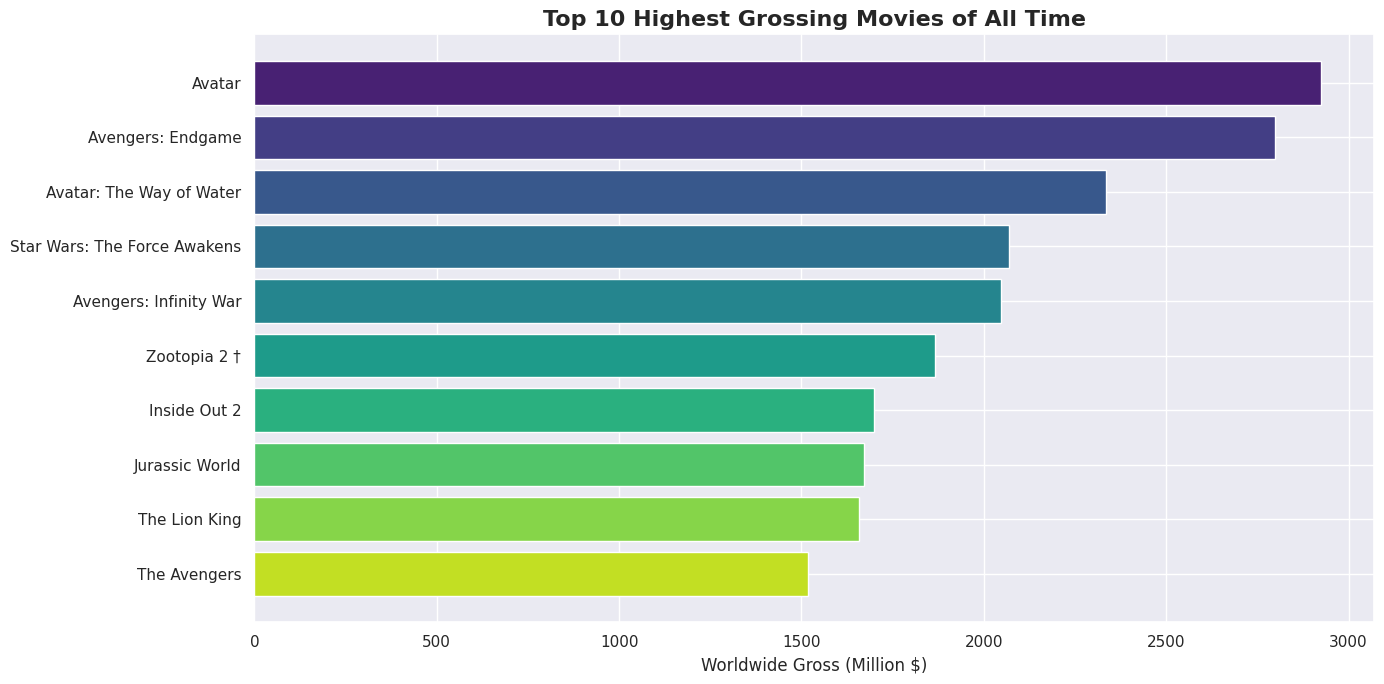

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"]=(12, 6)

# Chart 1-Top 10 Highest Grossing Movies
top10=df.head(10)

plt.figure(figsize=(14, 7))
bars=plt.barh(top10["Title"],top10["Gross (Million $)"],color=sns.color_palette("viridis",10))
plt.xlabel("Worldwide Gross (Million $)")
plt.title("Top 10 Highest Grossing Movies of All Time",fontsize=16,fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top10_movies.png",dpi=150)
plt.show()


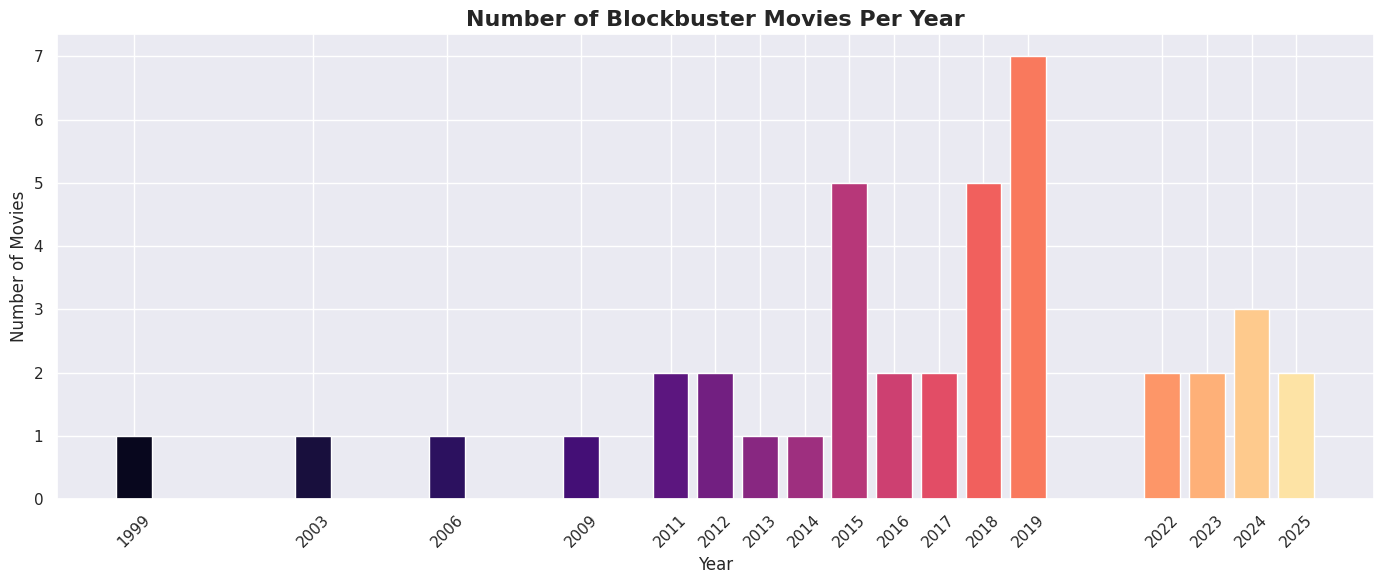

In [9]:
# Chart 2-Number of Blockbusters Per Year
plt.figure(figsize=(14, 6))
year_counts=df["Year"].value_counts().sort_index()
plt.bar(year_counts.index,year_counts.values,color=sns.color_palette("magma",len(year_counts)))
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Number of Blockbuster Movies Per Year",fontsize=16,fontweight="bold")
plt.xticks(year_counts.index,rotation=45)
plt.tight_layout()
plt.savefig("movies_per_year.png",dpi=150)
plt.show()


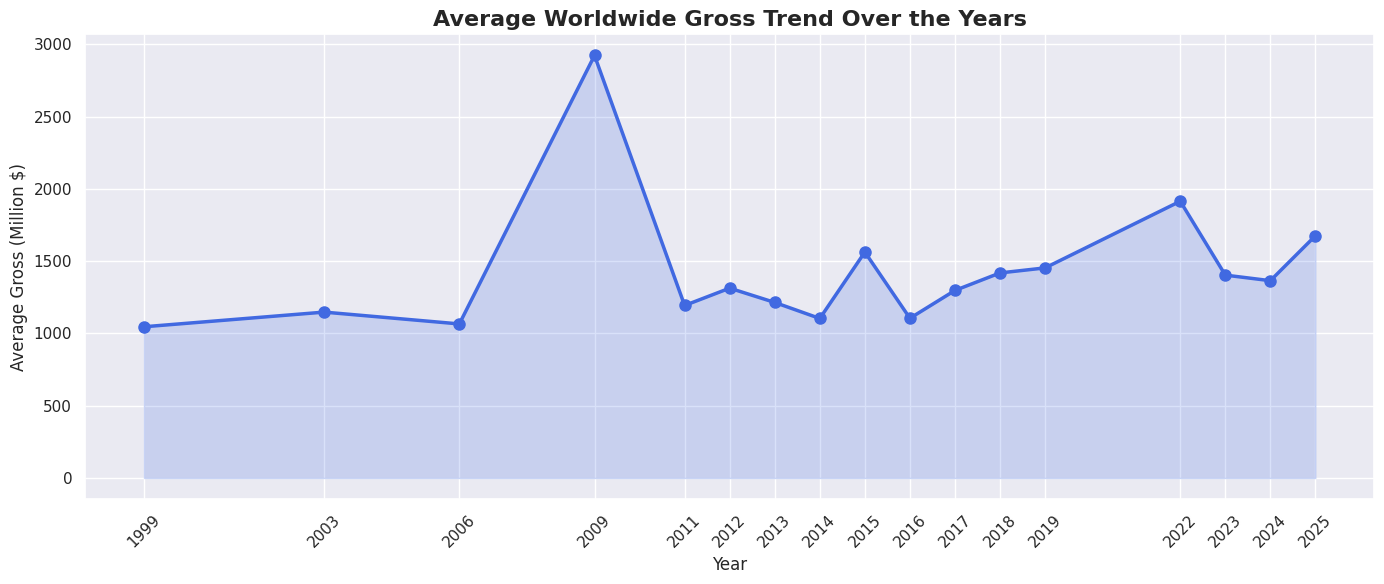

In [10]:
# Chart 3 - Worldwide Gross Over the Years (Trend Line)
plt.figure(figsize=(14,6))
yearly_avg=df.groupby("Year")["Gross (Million $)"].mean()
plt.plot(yearly_avg.index,yearly_avg.values,marker="o",color="royalblue",linewidth=2.5,markersize=8)
plt.fill_between(yearly_avg.index,yearly_avg.values,alpha=0.2,color="royalblue")
plt.xlabel("Year")
plt.ylabel("Average Gross (Million $)")
plt.title("Average Worldwide Gross Trend Over the Years",fontsize=16,fontweight="bold")
plt.xticks(yearly_avg.index,rotation=45)
plt.tight_layout()
plt.savefig("gross_trend.png",dpi=150)
plt.show()


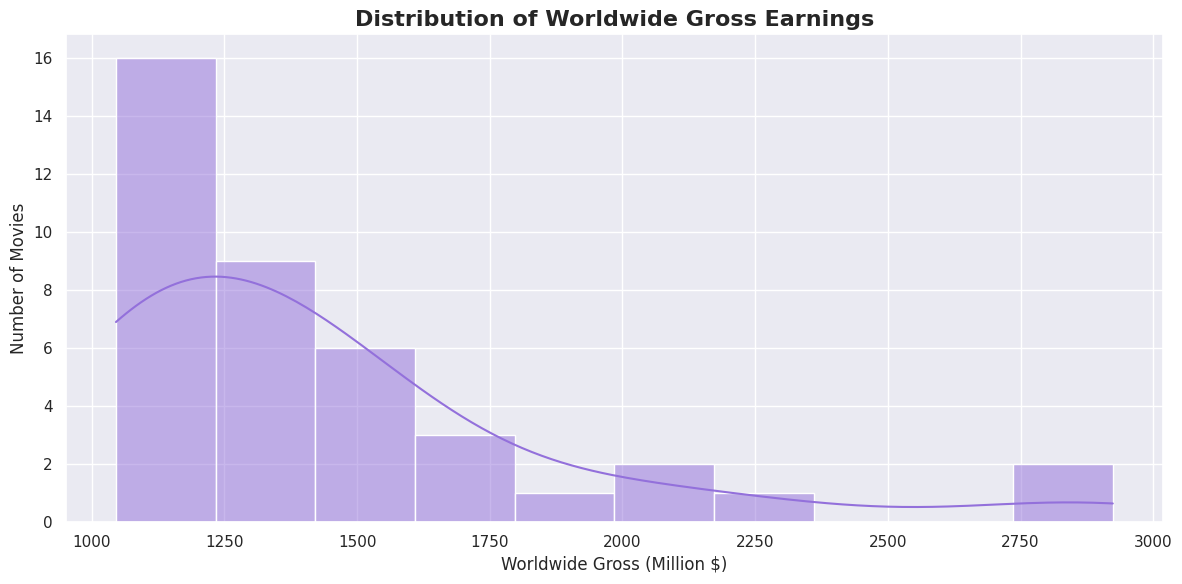

In [12]:
# Chart 4-Distribution of Worldwide Gross
plt.figure(figsize=(12,6))
sns.histplot(df["Gross (Million $)"],bins=10,kde=True,color="mediumpurple")
plt.xlabel("Worldwide Gross (Million $)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Worldwide Gross Earnings",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.savefig("gross_distribution.png",dpi=150)
plt.show()


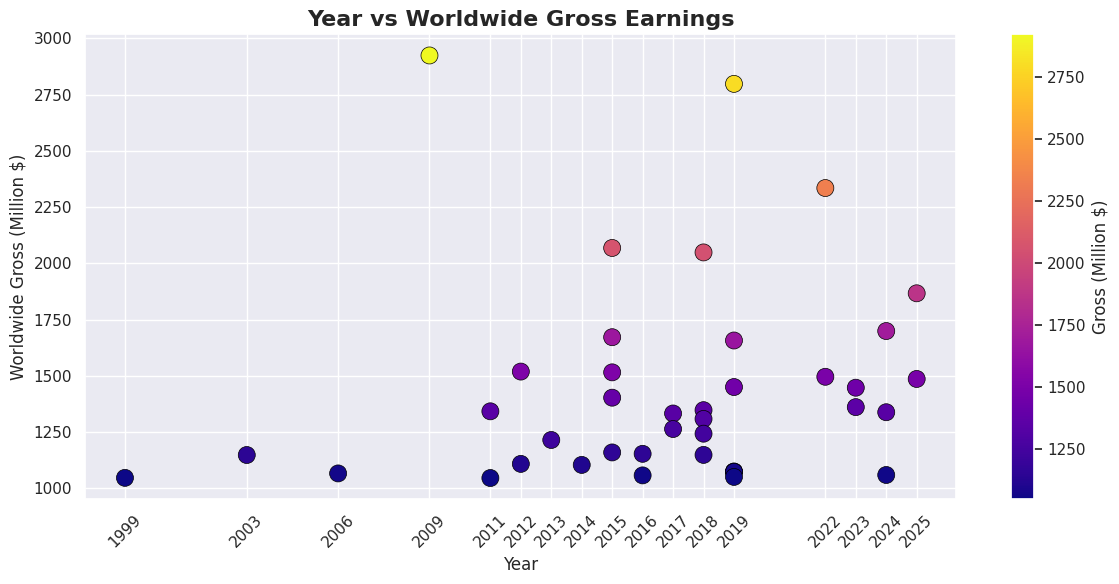

In [14]:
# Chart 5 - Year vs Worldwide Gross (Scatter Plot)
plt.figure(figsize=(12,6))
scatter=plt.scatter(df["Year"],df["Gross (Million $)"],
                      c=df["Gross (Million $)"],
                      cmap="plasma",
                      s=150,
                      edgecolors="black",
                      linewidth=0.5)
plt.colorbar(scatter,label="Gross (Million $)")
plt.xlabel("Year")
plt.ylabel("Worldwide Gross (Million $)")
plt.title("Year vs Worldwide Gross Earnings",fontsize=16,fontweight="bold")
plt.xticks(df["Year"].unique(),rotation=45)
plt.tight_layout()
plt.savefig("year_vs_gross.png",dpi=150)
plt.show()


## Key Insights

In [17]:
print("="*45)
print("KEY INSIGHTS FROM EDA")
print("="*45)

print(f"\nHighest Grossing Movie:{df.iloc[0]['Title']} (${df.iloc[0]['Gross (Million $)']}M) in {df.iloc[0]['Year']}")
print(f"\nMost Productive Year:{df['Year'].value_counts().idxmax()} ({df['Year'].value_counts().max()} blockbusters)")
print(f"\nAverage Gross of Top 40:${round(df['Gross (Million $)'].mean(), 2)}M")
print(f"\nHighest Avg Gross Year:{df.groupby('Year')['Gross (Million $)'].mean().idxmax()}")
print(f"\nMost Recent Blockbuster:{df[df['Year'] == df['Year'].max()].iloc[0]['Title']} ({df['Year'].max()})")
print(f"\nGross Std Deviation:${round(df['Gross (Million $)'].std(), 2)}M")

KEY INSIGHTS FROM EDA

Highest Grossing Movie:Avatar ($2923.71M) in 2009

Most Productive Year:2019 (7 blockbusters)

Average Gross of Top 40:$1437.56M

Highest Avg Gross Year:2009

Most Recent Blockbuster:Zootopia 2 † (2025)

Gross Std Deviation:$453.2M


## Conclusion

This Exploratory Data Analysis uncovered key patterns in the Top 40 Highest-Grossing Movies of All Time.

**Key Findings:**
- Avatar (2009) remains the highest grossing movie at $2,923.71M

- 2019 was the most dominant year with 7 blockbusters in the top 40
- The average gross earnings of the top 40 movies is $1,437.56M
- Box office earnings show an upward trend over the decades with occasional spikes
- Most blockbusters are concentrated between 2015–2025 showing the rise of franchise films
- The wide standard deviation indicates a large gap between mega-hits and regular blockbusters

**Visualizations Created:**
- Top 10 Highest Grossing Movies (Bar Chart)

- Number of Blockbusters Per Year (Bar Chart)
- Average Gross Trend Over Years (Line Chart)
- Distribution of Gross Earnings (Histogram)
- Year vs Gross Earnings (Scatter Plot)